In [1]:
# Importing PyTorch and configure GPU usage

import torch
torch.cuda.set_per_process_memory_fraction(0.5, device=2)

device = torch.device("cuda:2")

In [ ]:
# Checking CUDA availability and display the installed CUDA version used by PyTorch

import torch
print(torch.cuda.is_available())  
print(torch.version.cuda)         

True
11.7


In [ ]:
# List all available GPUs with their names and current allocated and reserved (cached) memory usage

import torch

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}, Memory Allocated: {torch.cuda.memory_allocated(i)/1024**3:.2f} GB, Cached: {torch.cuda.memory_reserved(i)/1024**3:.2f} GB")

GPU 0: NVIDIA GeForce GTX 1080 Ti, Memory Allocated: 0.00 GB, Cached: 0.00 GB
GPU 1: NVIDIA GeForce GTX 1080 Ti, Memory Allocated: 0.00 GB, Cached: 0.00 GB
GPU 2: NVIDIA GeForce GTX 1080 Ti, Memory Allocated: 0.00 GB, Cached: 0.00 GB


In [ ]:
# Importing required libraries

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import cohen_kappa_score


In [ ]:
# Defining directory paths for training, validation and test datasets

train_path = "/home/group2/DLC1/train"
val_path   = "/home/group2/DLC1/val"
test_path  = "/home/group2/DLC1/test-2Class"

In [ ]:
# Setting image input size, number of output classes and corresponding class labels

img_size = 224
num_classes = 2
class_names = ["Nevus", "Other"]

In [ ]:
# Defining data augmentation for training and validation

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
# Creating a custom dataset with fixed class to index mapping and initialize training and validation datasets

class CustomDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform)
        self.class_to_idx = {"Nevus": 0, "Other": 1}
        self.idx_to_class = {0: "Nevus", 1: "Other"}

train_ds = CustomDataset(train_path, train_tf)
val_ds   = CustomDataset(val_path, val_tf)

class_names = ["Nevus", "Other"]

In [ ]:
# Computing class weights for handling imbalance, creating a weighted sampler for the training set and define DataLoaders for training and validation

targets = [y for _, y in train_ds]
class_counts = np.bincount(targets)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)

sampler = WeightedRandomSampler(
    weights=[class_weights[t] for t in targets],
    num_samples=len(targets)
)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)


In [ ]:
# Defining Focal Loss for imbalanced classification

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight)

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma) * ce_loss

In [ ]:
# Loading a pre-trained model (VGG19, ResNet50, EfficientNet-B3 and ConvNeXt-Tiny)

def get_model(name):
    if name == "VGG19":
        model = models.vgg19(weights="IMAGENET1K_V1")
        model.classifier[6] = nn.Linear(4096, 2)

    elif name == "ResNet50":
        model = models.resnet50(weights="IMAGENET1K_V1")
        model.fc = nn.Linear(model.fc.in_features, 2)

    elif name == "EfficientNet-B3":
        model = models.efficientnet_b3(weights="IMAGENET1K_V1")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

    elif name == "ConvNeXt-Tiny":
        model = models.convnext_tiny(weights="IMAGENET1K_V1")
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)

    else:
        raise ValueError("Unknown model")

    return model.to(device)

In [ ]:
# Training the model using Focal Loss and AdamW optimizer with cosine annealing scheduler, 
# Evaluating on validation set each epoch, compute accuracy and Cohen's kappa, 
# Implementing early stopping and save the best model weights.

def train_model(model, name, epochs=25):
    criterion = FocalLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0
    patience, wait = 6, 0

    for epoch in range(epochs):
        model.train()
        correct = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct += (out.argmax(1) == y).sum().item()

        train_acc = correct / len(train_ds)

        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                preds = out.argmax(1)
                y_true.extend(y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        val_acc = np.mean(np.array(y_true) == np.array(y_pred))
        kappa = cohen_kappa_score(y_true, y_pred)

        print(f"{name} | Epoch {epoch+1} | Train {train_acc:.4f} | Val {val_acc:.4f} | Kappa {kappa:.4f}")

        scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"best_{name}.pt")
            wait = 0
        else:
            wait += 1
            if wait >= 6:
                print("Early stopping")
                break

    return best_acc, kappa


In [ ]:
# Training multiple pre-defined models sequentially, store their best validation accuracy and Cohen's kappa and print the final results.

models_to_run = ["VGG19", "ResNet50", "EfficientNet-B3", "ConvNeXt-Tiny"]
results = {}

for name in models_to_run:
    print(f"\n Training {name}")
    model = get_model(name)
    acc, kappa = train_model(model, name)
    results[name] = (acc, kappa)

print("\nFINAL RESULTS")
for k, v in results.items():
    print(f"{k}: Accuracy={v[0]:.4f}, Kappa={v[1]:.4f}")


 Training VGG19
VGG19 | Epoch 1 | Train 0.5941 | Val 0.6035 | Kappa 0.2174
VGG19 | Epoch 2 | Train 0.5493 | Val 0.6623 | Kappa 0.3244
VGG19 | Epoch 3 | Train 0.6186 | Val 0.5793 | Kappa 0.1693
VGG19 | Epoch 4 | Train 0.6681 | Val 0.7466 | Kappa 0.4940
VGG19 | Epoch 5 | Train 0.7333 | Val 0.7835 | Kappa 0.5674
VGG19 | Epoch 6 | Train 0.7568 | Val 0.7771 | Kappa 0.5552
VGG19 | Epoch 7 | Train 0.7633 | Val 0.7835 | Kappa 0.5658
VGG19 | Epoch 8 | Train 0.7659 | Val 0.7848 | Kappa 0.5706
VGG19 | Epoch 9 | Train 0.7801 | Val 0.7769 | Kappa 0.5540
VGG19 | Epoch 10 | Train 0.7758 | Val 0.7806 | Kappa 0.5612
VGG19 | Epoch 11 | Train 0.7878 | Val 0.7995 | Kappa 0.5994
VGG19 | Epoch 12 | Train 0.7839 | Val 0.7914 | Kappa 0.5811
VGG19 | Epoch 13 | Train 0.7955 | Val 0.8080 | Kappa 0.6158
VGG19 | Epoch 14 | Train 0.7995 | Val 0.8022 | Kappa 0.6039
VGG19 | Epoch 15 | Train 0.7991 | Val 0.8122 | Kappa 0.6248
VGG19 | Epoch 16 | Train 0.8057 | Val 0.8217 | Kappa 0.6431
VGG19 | Epoch 17 | Train 0.8053 


 VGG19 Results
              precision    recall  f1-score   support

       Nevus       0.83      0.83      0.83      1931
       Other       0.82      0.82      0.82      1865

    accuracy                           0.83      3796
   macro avg       0.83      0.83      0.83      3796
weighted avg       0.83      0.83      0.83      3796



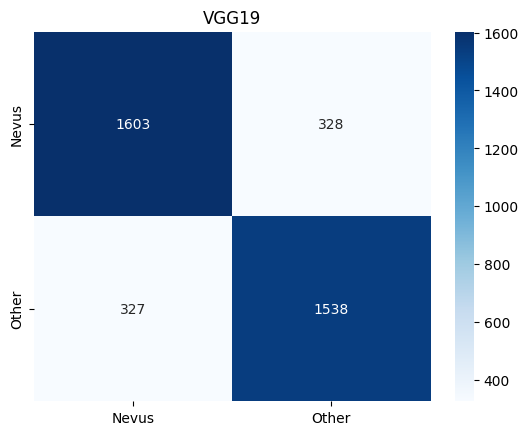


 ResNet50 Results
              precision    recall  f1-score   support

       Nevus       0.87      0.88      0.87      1931
       Other       0.88      0.86      0.87      1865

    accuracy                           0.87      3796
   macro avg       0.87      0.87      0.87      3796
weighted avg       0.87      0.87      0.87      3796



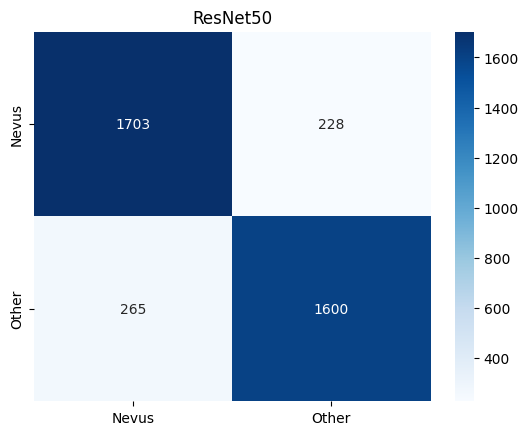


 EfficientNet-B3 Results
              precision    recall  f1-score   support

       Nevus       0.89      0.93      0.91      1931
       Other       0.92      0.88      0.90      1865

    accuracy                           0.90      3796
   macro avg       0.91      0.90      0.90      3796
weighted avg       0.90      0.90      0.90      3796



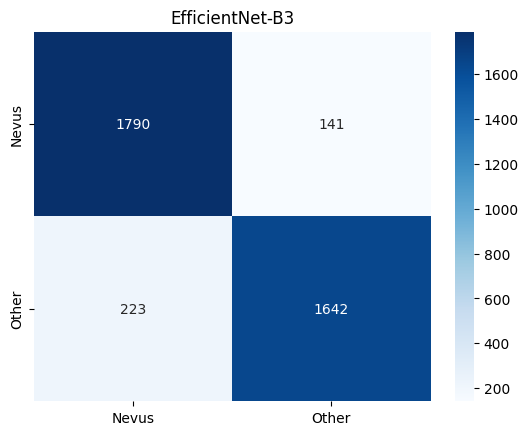


 ConvNeXt-Tiny Results
              precision    recall  f1-score   support

       Nevus       0.91      0.90      0.90      1931
       Other       0.90      0.90      0.90      1865

    accuracy                           0.90      3796
   macro avg       0.90      0.90      0.90      3796
weighted avg       0.90      0.90      0.90      3796



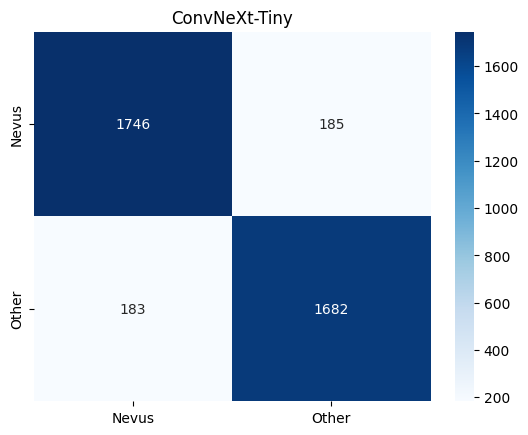

In [ ]:
# Loading the best saved model for each architecture, evaluate on the validation set, 
# Printing the classification report and visualize the confusion matrix using a heatmap.

for name in models_to_run:
    print(f"\n {name} Results")
    model = get_model(name)
    model.load_state_dict(torch.load(f"best_{name}.pt"))
    model.eval()

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(name)
    plt.show()

In [ ]:
# Perform inference on the test set using the best saved model, 
# Predicting labels for each image and save the results to a CSV file.

best_model_name = "EfficientNet-B3"   
test_path = "/home/group2/DLC1/test-2Class"

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted([f for f in os.listdir(root)
                              if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root, img_name)
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, img_name


test_ds = TestDataset(test_path, test_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model = get_model(best_model_name)
model.load_state_dict(torch.load(f"best_{best_model_name}.pt", map_location=device))
model.to(device)
model.eval()

predictions = []

with torch.no_grad():
    for imgs, names in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        for name, pred in zip(names, preds):
            predictions.append([name, int(pred)])

df = pd.DataFrame(predictions, columns=["image_name", "label"])
df.to_csv(f"test_predictions_{best_model_name}.csv", index=False)

print(f"Saved to test_predictions_{best_model_name}.csv")

Saved to test_predictions_EfficientNet-B3.csv
